In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [77]:
df= pd.read_csv(r"C:\Users\Dell\Desktop\loan-default-prediction\data\loan_data.csv")

In [78]:
if "Unnamed:0" in df.columns:
    df.drop(columns("Unnamed:0", inplace=True))
    

In [79]:
print(f"{df.shape[0]},rows {df.shape[1]} columns")

150000,rows 12 columns


In [80]:
null= df.isna().sum()
print(null)

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64


In [81]:
before=len(df)
print(before)

150000


In [82]:
after=df.drop_duplicates()
print(after)

        Unnamed: 0  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  \
0                1                 1                              0.766127   
1                2                 0                              0.957151   
2                3                 0                              0.658180   
3                4                 0                              0.233810   
4                5                 0                              0.907239   
...            ...               ...                                   ...   
149995      149996                 0                              0.040674   
149996      149997                 0                              0.299745   
149997      149998                 0                              0.246044   
149998      149999                 0                              0.000000   
149999      150000                 0                              0.850283   

        age  NumberOfTime30-59DaysPastDueNotWorse    DebtRatio 

In [83]:
df=df[df['age']>0]
df=df[df['age']<100]
df=df[df['MonthlyIncome']>=0]
df=df[df['DebtRatio']>=0]

In [84]:
df

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
149994,149995,0,0.385742,50,0,0.404293,3400.0,7,0,0,0,0.0
149995,149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149998,149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [85]:
outlier_cols = []
numeric_col= df.select_dtypes(include=['int64','float64']).columns
for col in numeric_col:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    lw=q1-1.5*iqr
    up=q3+1.5*iqr
    outliers=((df[col]<lw)|(df[col]>up)).sum()
    if outliers > 0:
        print(f"{col}: {outliers} outliers found")
        outlier_cols.append(col)
      


SeriousDlqin2yrs: 8356 outliers found
RevolvingUtilizationOfUnsecuredLines: 543 outliers found
age: 111 outliers found
NumberOfTime30-59DaysPastDueNotWorse: 20297 outliers found
DebtRatio: 7357 outliers found
MonthlyIncome: 4879 outliers found
NumberOfOpenCreditLinesAndLoans: 3472 outliers found
NumberOfTimes90DaysLate: 6725 outliers found
NumberRealEstateLoansOrLines: 680 outliers found
NumberOfTime60-89DaysPastDueNotWorse: 6275 outliers found
NumberOfDependents: 232 outliers found


In [86]:
outlier_cols

['SeriousDlqin2yrs',
 'RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

In [87]:
def cap_outliers(df, col, upper_percentile=95):
    upper = df[col].quantile(upper_percentile / 100)
    before_max = df[col].max()
    df[col] = df[col].clip(upper=upper)
    after_max = df[col].max()
    print(f"{col}: max before={before_max:.2f}  →  max after={after_max:.2f}")
    return df
print("\nCAPPING OUTLIERS")
print("="*40)


CAPPING OUTLIERS


In [88]:
for col in outlier_cols:
    df = cap_outliers(df, col)

print("\nOutlier capping done!")

SeriousDlqin2yrs: max before=1.00  →  max after=1.00
RevolvingUtilizationOfUnsecuredLines: max before=50708.00  →  max after=1.00
age: max before=99.00  →  max after=76.00
NumberOfTime30-59DaysPastDueNotWorse: max before=98.00  →  max after=2.00
DebtRatio: max before=61106.50  →  max after=1.13
MonthlyIncome: max before=3008750.00  →  max after=14587.95
NumberOfOpenCreditLinesAndLoans: max before=58.00  →  max after=18.00
NumberOfTimes90DaysLate: max before=98.00  →  max after=1.00
NumberRealEstateLoansOrLines: max before=54.00  →  max after=3.00
NumberOfTime60-89DaysPastDueNotWorse: max before=98.00  →  max after=1.00
NumberOfDependents: max before=20.00  →  max after=3.00

Outlier capping done!


In [89]:
print(f"\nFinal clean dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")



Final clean dataset: 120,262 rows x 12 columns


In [90]:
print("\nData types:")
print(df.dtypes)


Data types:
Unnamed: 0                                int64
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object


In [91]:
df.to_csv("../data/loan_data_clean.csv", index=False)
print("\nSaved to data/loan_data_clean.csv")



Saved to data/loan_data_clean.csv


In [92]:
df

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.00,13,0,3,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.00,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.00,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.00,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,14587.95,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
149994,149995,0,0.385742,50,0,0.404293,3400.00,7,0,0,0,0.0
149995,149996,0,0.040674,74,0,0.225131,2100.00,4,0,1,0,0.0
149996,149997,0,0.299745,44,0,0.716562,5584.00,4,0,1,0,2.0
149998,149999,0,0.000000,30,0,0.000000,5716.00,4,0,0,0,0.0


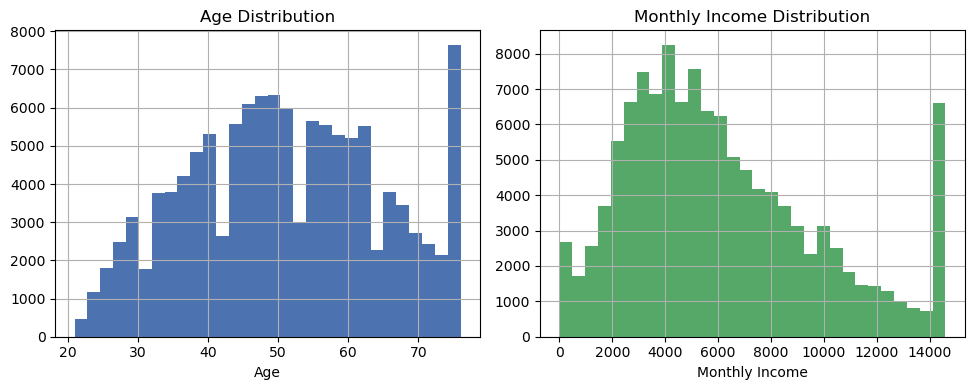

Chart saved to outputs/


In [93]:
# Plot distribution of age — just to visually confirm data looks clean
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df["age"].hist(bins=30, color="#4C72B0")
plt.title("Age Distribution")
plt.xlabel("Age")

plt.subplot(1, 2, 2)
df["MonthlyIncome"].hist(bins=30, color="#55A868")
plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")

plt.tight_layout()
plt.savefig("../outputs/day3_distributions.png")
plt.show()
print("Chart saved to outputs/")